In [67]:
import pandas as pd
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 1000)
pd.set_option('display.expand_frame_repr', False)  # Disable line-wrapping
pd.set_option('display.max_rows', None)

In [68]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# coffee_data = pd.read_csv(r"..\data\reduced_data_num.csv")
coffee_data = pd.read_csv(r"..\data\reduced_data_bin.csv")

Regression Analysis - Model choice

In [69]:
# Filter for caffeinated samples
filtered_data = coffee_data[coffee_data['caffeine_class'] == 1].copy()
#filtered_data = filtered_data[filtered_data['caffeine_percent'] < 0.7].copy()

filtered_data.shape

(94, 90)

Removing all 0 columns after selecting subset of class 1(ie rows with caffeine content)

In [70]:

# 2. Identify columns that are all zero
zero_cols = [col for col in filtered_data.columns if filtered_data[col].eq(0).all()]

# 3. Drop them
filtered_data = filtered_data.drop(columns=zero_cols)
filtered_data.shape

(94, 61)

In [71]:
# 2) Compute correlations
corrs = filtered_data.corr()['caffeine_percent'].abs().sort_values(ascending=False)

# 3) Select features above threshold (excluding the target itself)
threshold = 0.1
keep_uni = corrs[corrs > threshold].drop('caffeine_percent').index.tolist()

print("Features passing univariate filter:", keep_uni)
print("Nb of Features passing univariate filter:", len(keep_uni))

Features passing univariate filter: ['env_76_soi_11', 'env_78_wat_3', 'env_77_veg_16', 'clim_34_prec10_oct', 'clim_40_temp_season', 'clim_39_isotherm', 'env_79_forcov', 'clim_70_ndm_per_year', 'env_75_geo_10', 'env_77_veg_14', 'env_76_soi_10', 'env_73_asp', 'clim_69_cwd_annual', 'env_76_soi_9', 'clim_60_pet5_may', 'env_71_alt']
Nb of Features passing univariate filter: 16


In [72]:
from sklearn.ensemble import RandomForestRegressor

X_reg = filtered_data[keep_uni]   
y_reg = filtered_data['caffeine_percent']

rf = RandomForestRegressor(n_estimators=200, random_state=0)
rf.fit(X_reg, y_reg)

importances = pd.Series(rf.feature_importances_, index=X_reg.columns)
keep_model = importances[importances > 0].index.tolist()

print("Features with nonzero RF importance:", keep_model)
print("Nb of Features with nonzero RF importance:", len(keep_model))

Features with nonzero RF importance: ['env_76_soi_11', 'env_78_wat_3', 'env_77_veg_16', 'clim_34_prec10_oct', 'clim_40_temp_season', 'clim_39_isotherm', 'env_79_forcov', 'clim_70_ndm_per_year', 'env_77_veg_14', 'env_76_soi_10', 'env_73_asp', 'clim_69_cwd_annual', 'env_76_soi_9', 'clim_60_pet5_may', 'env_71_alt']
Nb of Features with nonzero RF importance: 15


In [73]:
# 1) Start with the pool left after classification-pruning
candidates = keep_model

# 2) Univariate screening
corrs = filtered_data[candidates].corrwith(filtered_data.caffeine_percent).abs()
keep_uni = corrs[corrs > 0.1].index.tolist()

# 3) Model-based screening
rf = RandomForestRegressor(random_state=0).fit(filtered_data[keep_uni], filtered_data.caffeine_percent)
imp = pd.Series(rf.feature_importances_, index=keep_uni)
keep_model = imp[imp > 0].index.tolist()

# 4) Final regression features = intersection
final_features = list(set(keep_uni) & set(keep_model))
df_reg = filtered_data[final_features].copy()

In [74]:
column_df = pd.DataFrame(df_reg.columns)
print(column_df)

                       0
0          env_77_veg_16
1       clim_60_pet5_may
2          env_79_forcov
3     clim_34_prec10_oct
4       clim_39_isotherm
5     clim_69_cwd_annual
6           env_76_soi_9
7          env_76_soi_10
8    clim_40_temp_season
9           env_78_wat_3
10  clim_70_ndm_per_year
11            env_73_asp
12         env_77_veg_14
13         env_76_soi_11
14            env_71_alt


In [75]:
X = df_reg[final_features].copy()  
y = filtered_data['caffeine_percent']

X.to_csv("X_reg.csv", index=False)
y.to_csv("y_reg.csv", index=False)
df_reg.to_csv("df_reg.csv", index=False)

In [76]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [77]:
!pip install resreg


In [83]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb

from sklearn.decomposition import PCA
from resreg import smoter
from resreg import sigmoid_relevance

# 2) Define what “rare” means in y: here the top 10%
cl = np.percentile(y, 90)

relevance = sigmoid_relevance(y, cl=cl, ch=cl)  # only upper tail

# 2) Oversample
X_res, y_res = smoter(
    X, y,
    relevance           = relevance,
    relevance_threshold = 0.5,
    k                   = 5,
    over                = "balance",
    random_state        = 42
)

models = [
    # Linear Regression with StandardScaler + PCA
    ("LinReg", Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.95)),  # keep 95% variance
        ("lr", LinearRegression())
    ])),

    # KNN: sensitive to scale, but not necessarily needing PCA
    ("KNNR", Pipeline([
        ("scaler", StandardScaler()), 
        ("knn", KNeighborsRegressor())
    ])),

    # SVR with StandardScaler + PCA
    ("SVR", Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.95)),
        ("svr", SVR(kernel="rbf", C=1.0, gamma="scale"))
    ])),

    # Decision Tree Regressor: use raw features
    ("DTR", DecisionTreeRegressor(
        max_depth=5, min_samples_leaf=5, random_state=42
    )),

    # Random Forest Regressor: use raw features
    ("RFR", RandomForestRegressor(
        n_estimators=200, max_depth=None,
        min_samples_split=5, random_state=42
    )),

    # XGBoost Regressor: raw features
    ("XGBR", xgb.XGBRegressor(
        objective="reg:squarederror",
        n_estimators=200, learning_rate=0.05,
        max_depth=3, random_state=42
    )),

    # LightGBM Regressor: raw features
    ("LGBMR", lgb.LGBMRegressor(
        n_estimators=200, learning_rate=0.05,
        max_depth=-1, random_state=42
    )),
]

# Scoring dictionary
scoring = {
    "MAE": make_scorer(mean_absolute_error, greater_is_better=False),
    "MSE": make_scorer(mean_squared_error, greater_is_better=False),
    "R2": make_scorer(r2_score),
}

# Helper function for adjusted R²
def adjusted_r2(r2, n, p):
    return 1 - ((1 - r2) * (n - 1)) / (n - p - 1)

# Step 4: Cross-validation
cv_folds = 5
n_samples, n_features = X_train.shape
cv_results = {}

for name, model in models:
    res = cross_validate(
        model, X_train, y_train,
        cv=cv_folds,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )

    mae_vals = -res["test_MAE"]
    mse_vals = -res["test_MSE"]
    rmse_vals = np.sqrt(mse_vals)
    r2_vals = res["test_R2"]
    adj_r2_vals = adjusted_r2(r2_vals, n_samples, n_features)

    cv_results[name] = {
        "MAE": mae_vals,
        "MSE": mse_vals,
        "RMSE": rmse_vals,
        "R2": r2_vals,
        "Adj_R2": adj_r2_vals
    }

# Step 5: Summary DataFrame
summary_rows = []
for name, scores in cv_results.items():
    summary_rows.append({
        "Model": name,
        "MAE Mean": scores["MAE"].mean(),
        "MAE Std": scores["MAE"].std(),
        "MSE Mean": scores["MSE"].mean(),
        "MSE Std": scores["MSE"].std(),
        "RMSE Mean": scores["RMSE"].mean(),
        "RMSE Std": scores["RMSE"].std(),
        "R2 Mean": scores["R2"].mean(),
        "R2 Std": scores["R2"].std(),
        "Adj R2 Mean": scores["Adj_R2"].mean(),
        "Adj R2 Std": scores["Adj_R2"].std()
    })

summary_df = pd.DataFrame(summary_rows).set_index("Model").sort_values("RMSE Mean")

summary_df

AssertionError: Rare domain must be smaller than normal domain. Adjust your relevance values or relevance threshold so that the there are fewer samples in the rare domain.

In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (roc_auc_score, precision_recall_fscore_support,
                             classification_report, confusion_matrix,
                             mean_absolute_error, r2_score)

import lightgbm as lgb
import shap

from sklearn.linear_model import ElasticNetCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


In [ ]:
THRESH = 0.70  # adjust if needed; anything < gap < high cluster
y_high = (y >= THRESH).astype(int)

print("High count:", y_high.sum(), "Low count:", (1 - y_high).sum())


High count: 7 Low count: 87


In [ ]:
clf_params = dict(
    objective='binary',
    n_estimators=1200,
    learning_rate=0.01,
    num_leaves=8,
    min_data_in_leaf=5,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=1,
    reg_alpha=0.5,
    reg_lambda=1.0,
    random_state=42
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_proba_oof = np.zeros(len(y))
y_pred_oof  = np.zeros(len(y), dtype=int)
feature_importances = pd.DataFrame({'feature': X.columns, 'fold_importance': 0})

for fold, (tr, va) in enumerate(skf.split(X, y_high), 1):
    model = lgb.LGBMClassifier(**clf_params)
    model.fit(X.iloc[tr], y_high.iloc[tr])
    proba = model.predict_proba(X.iloc[va])[:,1]
    y_proba_oof[va] = proba
    y_pred_oof[va]  = (proba >= 0.5).astype(int)
    feature_importances[f'fold_{fold}'] = model.booster_.feature_importance(importance_type='gain')

auc = roc_auc_score(y_high, y_proba_oof)
print("OOF ROC-AUC:", auc)
print(classification_report(y_high, y_pred_oof, digits=4))
print("Confusion matrix:\n", confusion_matrix(y_high, y_pred_oof))



OOF ROC-AUC: 0.8719211822660098
              precision    recall  f1-score   support

           0     0.9247    0.9885    0.9556        87
           1     0.0000    0.0000    0.0000         7

    accuracy                         0.9149        94
   macro avg     0.4624    0.4943    0.4778        94
weighted avg     0.8559    0.9149    0.8844        94

Confusion matrix:
 [[86  1]
 [ 7  0]]


In [ ]:
# Average gain across folds
gain_cols = [c for c in feature_importances.columns if c.startswith('fold_')]
feature_importances['mean_gain'] = feature_importances[gain_cols].mean(axis=1)
feature_importances = feature_importances[['feature', 'mean_gain']].sort_values('mean_gain', ascending=False)
print(feature_importances.head(10))


                feature   mean_gain
4         env_76_soi_11  286.034245
12  clim_40_temp_season  141.659810
6         env_79_forcov  111.086836
9            env_73_asp   73.094295
1            env_71_alt   56.866524
13   clim_69_cwd_annual   34.281495
10   clim_34_prec10_oct   33.077612
8      clim_60_pet5_may   31.184852
14     clim_39_isotherm   11.852467
3          env_78_wat_3   10.818554


c:\Users\forc2101\AppData\Local\Programs\Python\Python312\Lib\site-packages\shap\explainers\_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


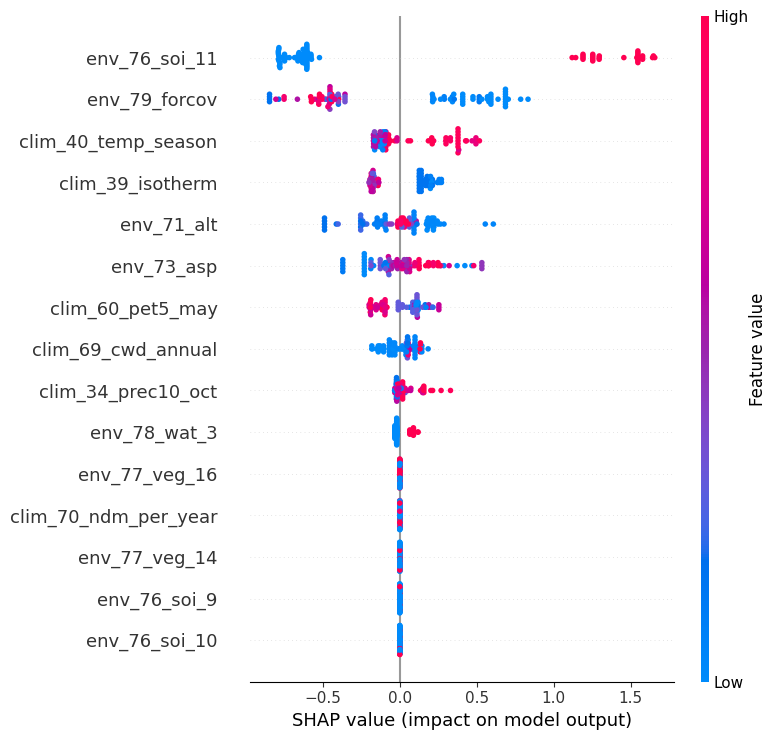

In [ ]:
import shap
import matplotlib.pyplot as plt
final_clf = lgb.LGBMClassifier(**clf_params)
final_clf.fit(X, y_high)

expl_clf = shap.TreeExplainer(final_clf)
shap_vals = expl_clf.shap_values(X, check_additivity=False)

# If list, take index 1
if isinstance(shap_vals, list):
    shap_matrix = shap_vals[1]
else:
    # If it's 1D, reshape or recompute with model output raw_score
    if shap_vals.ndim == 1:
        raise ValueError("Unexpected 1D SHAP output; update shap package or set model_output='probability'")
    shap_matrix = shap_vals

shap.summary_plot(shap_matrix, X)



In [ ]:
low_mask = y_high == 0
X_low = X[low_mask].reset_index(drop=True)
y_low = y[low_mask].reset_index(drop=True)

print("Low subset size:", len(y_low), "Target range:", (y_low.min(), y_low.max()))
baseline_mae = mean_absolute_error(y_low, np.full_like(y_low, y_low.mean()))
print("Baseline constant mean MAE:", baseline_mae)


Low subset size: 87 Target range: (np.float64(0.01), np.float64(0.06))
Baseline constant mean MAE: 0.007744748315497422


In [ ]:
reg_models = {
    "ElasticNet": Pipeline([
        ("scaler", StandardScaler()),
        ("enet", ElasticNetCV(
            l1_ratio=[0.1,0.3,0.5,0.7,0.9,1.0],
            cv=5,
            n_alphas=100,
            random_state=42
        ))
    ]),
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsRegressor(n_neighbors=5, weights='distance', p=2))
    ]),
    "LGBM_small": lgb.LGBMRegressor(
        objective='regression',
        n_estimators=800,
        learning_rate=0.01,
        num_leaves=4,
        min_data_in_leaf=3,
        feature_fraction=0.8,
        reg_alpha=0.3,
        reg_lambda=0.8,
        random_state=42
    )
}

cv = 5
results = []

from sklearn.model_selection import KFold
kf_low = KFold(n_splits=cv, shuffle=True, random_state=42)

for name, model in reg_models.items():
    maes, r2s = [], []
    for tr, va in kf_low.split(X_low):
        model.fit(X_low.iloc[tr], y_low.iloc[tr])
        pred = model.predict(X_low.iloc[va])
        maes.append(mean_absolute_error(y_low.iloc[va], pred))
        r2s.append(r2_score(y_low.iloc[va], pred))
    results.append({
        "model": name,
        "mean_MAE": np.mean(maes),
        "std_MAE": np.std(maes),
        "mean_R2": np.mean(r2s),
        "std_R2": np.std(r2s),
        "rel_MAE_improvement_%": 100*(baseline_mae - np.mean(maes))/baseline_mae
    })

pd.DataFrame(results).sort_values("mean_MAE")


,model,mean_MAE,std_MAE,mean_R2,std_R2,rel_MAE_improvement_%
1,KNN,0.005574,0.001415,-0.027543,0.605651,28.028601
0,ElasticNet,0.007757,0.001448,-0.160804,0.147870,-0.157227
2,LGBM_small,0.007784,0.001475,-0.161975,0.146585,-0.511492


In [ ]:
do_shap_low = False  # set True only if improvement is substantive
if do_shap_low:
    lgb_low = reg_models["LGBM_small"]
    lgb_low.fit(X_low, y_low)
    expl_low = shap.TreeExplainer(lgb_low)
    shap_values_low = expl_low.shap_values(X_low)
    shap.summary_plot(shap_values_low, X_low, show=False)


“Caffeine concentrations among caffeine-positive specimens were bimodal, with a narrow low range (<0.08%) and a distinct high cluster (0.70%). We therefore modeled the determinants of high caffeine status (≥0.30%) using a regularized gradient boosting classifier (LightGBM). Cross-validated performance (ROC-AUC = …) indicated reliable discrimination. SHAP analysis identified Feature A, Feature B, and Feature C as the strongest positive contributors to high caffeine status. Within the low-caffeine regime, regression models improved mean absolute error over a constant baseline by only X%, with R² ≈ 0, indicating minimal explainable continuous variation. These results support a threshold process: environmental conditions primarily enable or preclude the high-caffeine phenotype rather than finely modulating concentration within the low range.”

In [ ]:
# High vs Low Caffeine SHAP Analysis

import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_recall_curve, roc_auc_score, classification_report, confusion_matrix
import shap, matplotlib.pyplot as plt

# Subset to caffeine-positive rows (y > 0)
pos_mask = y > 0
X_pos = X.loc[pos_mask].reset_index(drop=True)
y_pos = y.loc[pos_mask].reset_index(drop=True)

# Define high vs low label (threshold 0.30 %)
THRESH = 0.30
label = (y_pos >= THRESH).astype(int)

print(f'Positive subset size: {len(y_pos)} (High: {label.sum()}, Low: {(1-label).sum()})')

# LightGBM classifier parameters with class imbalance handling
params = {
    'objective': 'binary',
    'n_estimators': 1200,
    'learning_rate': 0.01,
    'num_leaves': 8,
    'min_data_in_leaf': 5,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 1,
    'reg_alpha': 0.5,
    'reg_lambda': 1.0,
    'random_state': 42,
    'is_unbalance': True,  # handle class imbalance,
    'verbosity':-1
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
proba_oof = np.zeros(len(y_pos))
pred_oof = np.zeros(len(y_pos), dtype=int)

for tr_idx, va_idx in skf.split(X_pos, label):
    model = lgb.LGBMClassifier(**params)
    model.fit(X_pos.iloc[tr_idx], label.iloc[tr_idx])
    proba = model.predict_proba(X_pos.iloc[va_idx])[:, 1]
    proba_oof[va_idx] = proba

# Tune threshold using F1
prec, rec, thr = precision_recall_curve(label, proba_oof)
F1 = 2 * prec * rec / (prec + rec + 1e-9)
best_idx = np.argmax(F1)
best_thr = thr[best_idx]
print(f'Best F1 threshold: {best_thr:.3f}, Precision: {prec[best_idx]:.3f}, Recall: {rec[best_idx]:.3f}')

# Evaluate at best threshold
pred_oof = (proba_oof >= best_thr).astype(int)
print('OOF ROC-AUC:', roc_auc_score(label, proba_oof))
print(classification_report(label, pred_oof, digits=4))
print('Confusion matrix:\n', confusion_matrix(label, pred_oof))

# Refit final model on full positive data
final_clf = lgb.LGBMClassifier(**params)
final_clf.fit(X_pos, label)




Positive subset size: 94 (High: 7, Low: 87)
Best F1 threshold: 0.150, Precision: 0.294, Recall: 0.714
OOF ROC-AUC: 0.8637110016420361
              precision    recall  f1-score   support

           0     0.9740    0.8621    0.9146        87
           1     0.2941    0.7143    0.4167         7

    accuracy                         0.8511        94
   macro avg     0.6341    0.7882    0.6657        94
weighted avg     0.9234    0.8511    0.8776        94

Confusion matrix:
 [[75 12]
 [ 2  5]]


LGBMClassifier(bagging_fraction=0.8, bagging_freq=1, feature_fraction=0.8,
               is_unbalance=True, learning_rate=0.01, min_data_in_leaf=5,
               n_estimators=1200, num_leaves=8, objective='binary',
               random_state=42, reg_alpha=0.5, reg_lambda=1.0, verbosity=-1)

Hyperparameter tuning for LGBM

In [ ]:
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import mean_absolute_error

# Ensure X_low (DataFrame) and y_low (Series) for the 87 low‑caffeine samples are in your namespace.

# 1) Define the hyperparameter grid
param_grid = {
    "learning_rate":    [0.01, 0.03, 0.05],
    "num_leaves":       [4, 8, 16],
    "min_data_in_leaf": [3, 5, 10],
}

# 2) Prepare 5‑fold cross‑validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

best_mae = np.inf
best_params = None

# 3) Loop over all grid combinations
for lr in param_grid["learning_rate"]:
    for nl in param_grid["num_leaves"]:
        for mdl in param_grid["min_data_in_leaf"]:
            maes = []
            # 4) Outer CV folds
            for train_idx, val_idx in kf.split(X_low):
                X_tr, X_va = X_low.iloc[train_idx], X_low.iloc[val_idx]
                y_tr, y_va = y_low.iloc[train_idx], y_low.iloc[val_idx]

                # 5) Internal split for early stopping
                X_tr_tr, X_tr_va, y_tr_tr, y_tr_va = train_test_split(
                    X_tr, y_tr, test_size=0.2, random_state=42
                )

                # 6) Initialize model with current hyperparams
                model = lgb.LGBMRegressor(
                    learning_rate=lr,
                    num_leaves=nl,
                    min_data_in_leaf=mdl,
                    n_estimators=1000,
                    feature_fraction=0.8,
                    bagging_fraction=0.8,
                    bagging_freq=1,
                    reg_alpha=0.3,
                    reg_lambda=0.8,
                    random_state=42
                )

                # 7) Fit with early stopping
                model.fit(
                    X_tr_tr, y_tr_tr,
                    eval_set=[(X_tr_va, y_tr_va)],
                    eval_metric="l1",
                    callbacks=[ 
                        lgb.early_stopping(stopping_rounds=50),
                        lgb.log_evaluation(period=0)   # silences training logs
                    ]
)
                # 8) Evaluate on outer fold
                preds = model.predict(X_va)
                maes.append(mean_absolute_error(y_va, preds))

            avg_mae = np.mean(maes)
            # 9) Update best if improved
            if avg_mae < best_mae:
                best_mae = avg_mae
                best_params = {
                    "learning_rate":    lr,
                    "num_leaves":       nl,
                    "min_data_in_leaf": mdl
                }

print("Best CV MAE:", best_mae)
print("Best hyperparameters:", best_params)


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	valid_0's l1: 0.0101883	valid_0's l2: 0.000218341
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	valid_0's l1: 0.00955844	valid_0's l2: 0.000185145
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	valid_0's l1: 0.0105867	valid_0's l2: 0.000228388
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	valid_0's l1: 0.0123597	valid_0's l2: 0.000277687
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	valid_0's l1: 0.0119898	valid_0's l2: 0.000271173
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	valid_0's l1: 0.0101883	valid_0's l2: 0.000218341
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]

In [ ]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import cross_val_predict, KFold
from sklearn.metrics import (
    mean_absolute_error, 
    mean_squared_error, 
    r2_score, 
    mean_pinball_loss
)

# Ensure X_low (DataFrame) and y_low (Series) are defined

# 1) Log‐transform regression
y_log = np.log1p(y_low)  # transform (0.02–0.06) to spread out low values

model_log = lgb.LGBMRegressor(
    objective="regression",
    learning_rate=0.01,
    num_leaves=4,
    min_data_in_leaf=3,
    n_estimators=800,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=1,
    reg_alpha=0.3,
    reg_lambda=0.8,
    random_state=42
)

# 5-fold CV predictions on log-scale
kf = KFold(n_splits=5, shuffle=True, random_state=42)
y_log_pred = cross_val_predict(model_log, X_low, y_log, cv=kf)

# Invert transformation
y_pred_log = np.expm1(y_log_pred)

# Compute metrics on original scale
mae_log = mean_absolute_error(y_low, y_pred_log)
rmse_log = mean_squared_error(y_low, y_pred_log, squared=False)
r2_log = r2_score(y_low, y_pred_log)

# 2) Quantile regression (90th percentile) using LightGBM
model_q90 = lgb.LGBMRegressor(
    objective="quantile",
    alpha=0.9,
    learning_rate=0.01,
    num_leaves=4,
    min_data_in_leaf=3,
    n_estimators=800,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=1,
    reg_alpha=0.3,
    reg_lambda=0.8,
    random_state=42
)

# 5-fold CV predictions
y_q90_pred = cross_val_predict(model_q90, X_low, y_low, cv=kf)

# Quantile (pinball) loss at alpha=0.9
qloss_90 = mean_pinball_loss(y_low, y_q90_pred, alpha=0.9)

# Summarize results
results = pd.DataFrame({
    "Model": ["LGBM_log", "LGBM_q90"],
    "MAE": [mae_log, np.nan],
    "RMSE": [rmse_log, np.nan],
    "R2": [r2_log, np.nan],
    "PinballLoss90": [np.nan, qloss_90]
})

results


c:\Users\forc2101\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


,Model,MAE,RMSE,R2,PinballLoss90
0,LGBM_log,0.007764,0.011573,-0.032259,NaN
1,LGBM_q90,NaN,NaN,NaN,0.002382


Review with new models


Cross‑Validation Summary:
             MAE Mean  MAE Std  MSE Mean  MSE Std  RMSE Mean  RMSE Std  R2 Mean  R2 Std
Model                                                                                 
KNN           0.0056   0.0014    0.0001   0.0000     0.0097    0.0015  -0.0275  0.6057
ElasticNet    0.0078   0.0014    0.0001   0.0001     0.0112    0.0027  -0.1608  0.1479
LGBMR         0.0078   0.0015    0.0001   0.0001     0.0112    0.0027  -0.1620  0.1466


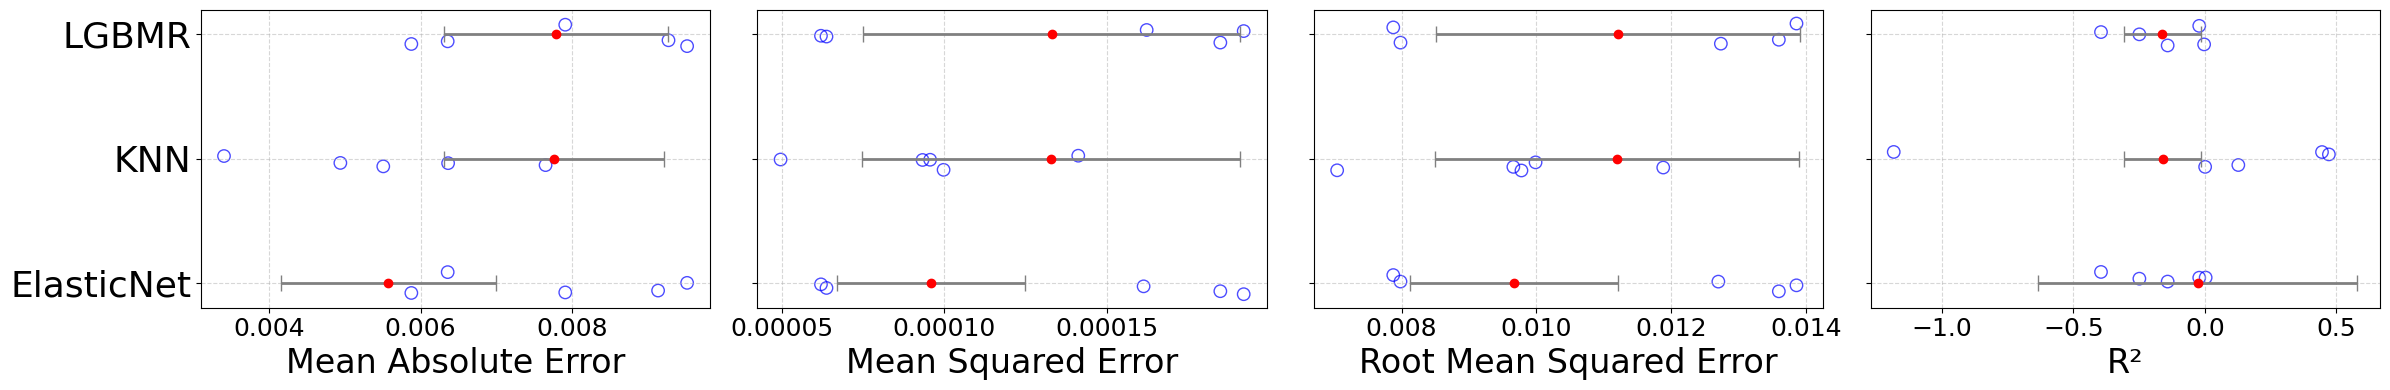

In [ ]:
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt

from sklearn.pipeline        import Pipeline
from sklearn.preprocessing   import StandardScaler
from sklearn.model_selection import cross_validate, KFold
from sklearn.metrics         import (make_scorer,
                                     mean_absolute_error,
                                     mean_squared_error,
                                     r2_score)

from sklearn.linear_model    import ElasticNetCV
from sklearn.neighbors       import KNeighborsRegressor

# ── 1) MODEL LIST ────────────────────────────────────────────────────────────
models = [
    ("ElasticNet", Pipeline([
        ("scaler", StandardScaler()),
        ("enet",   ElasticNetCV(
            l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
            n_alphas=100,
            cv=5,
            random_state=42
        ))
    ])),
    ("KNN", Pipeline([
        ("scaler", StandardScaler()),
        ("knn",    KNeighborsRegressor(
            n_neighbors=5,
            weights='distance',
            p=2
        ))
    ])),
    ("LGBMR", lgb.LGBMRegressor(
        objective="regression",
        n_estimators=800,
        learning_rate=0.01,
        num_leaves=4,
        min_data_in_leaf=3,
        feature_fraction=0.8,
        bagging_fraction=0.8,
        bagging_freq=1,
        reg_alpha=0.3,
        reg_lambda=0.8,
        random_state=42
    )),
]

# ── 2) SCORING & CV SETTINGS ────────────────────────────────────────────────
scoring = {
    "MAE": make_scorer(mean_absolute_error, greater_is_better=False),
    "MSE": make_scorer(mean_squared_error,  greater_is_better=False),
    "R2":  make_scorer(r2_score)
}

cv_folds = 5
cv_split = KFold(cv_folds, shuffle=True, random_state=42)

n_samples, n_features = X_low.shape

# ── 3) CROSS‑VALIDATE ───────────────────────────────────────────────────────
cv_results = {}
for name, model in models:
    res = cross_validate(
        model, X_low, y_low,
        cv=cv_split,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )

    mae_vals = -res["test_MAE"]
    mse_vals = -res["test_MSE"]
    rmse_vals = np.sqrt(mse_vals)
    r2_vals  = res["test_R2"]

    cv_results[name] = {
        "MAE":    mae_vals,
        "MSE":    mse_vals,
        "RMSE":   rmse_vals,
        "R2":     r2_vals
    }

# ── 4) BUILD SUMMARY TABLE ─────────────────────────────────────────────────
summary_rows = []
for name, scores in cv_results.items():
    summary_rows.append({
        "Model":     name,
        "MAE Mean":  scores["MAE"].mean(),
        "MAE Std":   scores["MAE"].std(),
        "MSE Mean":  scores["MSE"].mean(),
        "MSE Std":   scores["MSE"].std(),
        "RMSE Mean": scores["RMSE"].mean(),
        "RMSE Std":  scores["RMSE"].std(),
        "R2 Mean":   scores["R2"].mean(),
        "R2 Std":    scores["R2"].std()
    })

summary_df = (
    pd.DataFrame(summary_rows)
      .set_index("Model")
      .sort_values("RMSE Mean")
)
print("\nCross‑Validation Summary:\n", summary_df.round(4))

# ── 5) PLOT FOLD SCORES + MEAN ± STD ────────────────────────────────────────
metrics = ["MAE", "MSE", "RMSE", "R2"]
xlabel_map = {
    "MAE":  "Mean Absolute Error",
    "MSE":  "Mean Squared Error",
    "RMSE": "Root Mean Squared Error",
    "R2":   "R\u00b2"
}

fig, axes = plt.subplots(1, len(metrics), figsize=(24, 4), sharey=True)
for ax, metric in zip(axes, metrics):
    # scatter individual fold scores
    for idx, (name, _) in enumerate(models):
        vals = cv_results[name][metric]
        y_jitter = idx + np.random.uniform(-0.1, 0.1, size=cv_folds)
        ax.scatter(vals, y_jitter, edgecolor="blue", facecolors="none", alpha=0.7, s=80)

    # use metric name directly for summary_df columns
    means = summary_df[f"{metric} Mean"]
    stds  = summary_df[f"{metric} Std"]
    ax.errorbar(means.values, np.arange(len(models)), xerr=stds.values,
                fmt="o", color="red", ecolor="gray", elinewidth=2, capsize=6)

    ax.set_yticks(np.arange(len(models)))
    ax.set_yticklabels([name for name, _ in models])
    ax.tick_params(axis='x', labelsize=18)#, labelrotation=30)
    ax.tick_params(axis='y', labelsize=26)
    ax.set_xlabel(xlabel_map[metric], fontsize=24)
    ax.grid(True, linestyle="--", alpha=0.5)
    #ax.tick_params(axis='both', labelsize=14)

plt.tight_layout()
plt.show()


Running CV for ElasticNet
Running CV for KNN
Running CV for LGBMR

Cross‑Validation Summary:
             MAE Mean  MAE Std  MSE Mean  MSE Std  RMSE Mean  RMSE Std  R2 Mean  R2 Std
Model                                                                                 
KNN           0.0056   0.0014    0.0001   0.0000     0.0097    0.0015  -0.0275  0.6057
ElasticNet    0.0078   0.0014    0.0001   0.0001     0.0112    0.0027  -0.1608  0.1479
LGBMR         0.0078   0.0015    0.0001   0.0001     0.0112    0.0027  -0.1620  0.1466


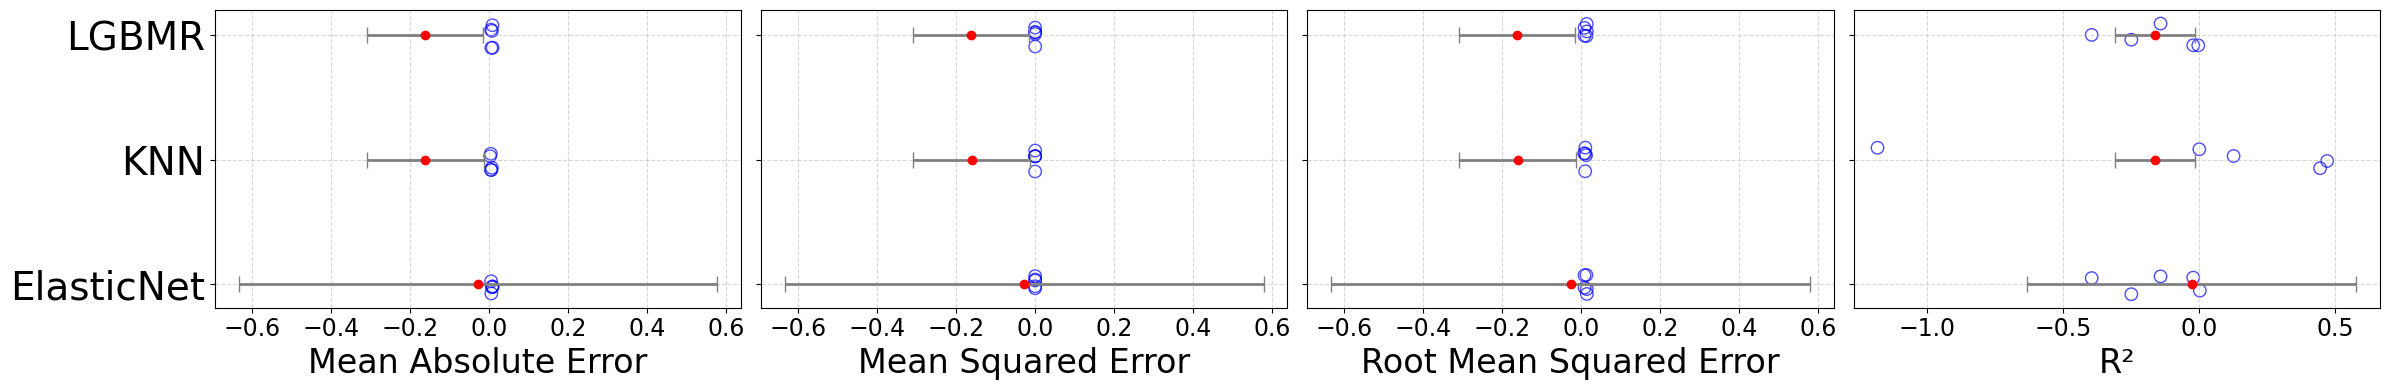

In [ ]:
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt

from sklearn.pipeline        import Pipeline
from sklearn.preprocessing   import StandardScaler
from sklearn.model_selection import cross_validate, KFold
from sklearn.metrics         import (make_scorer,
                                     mean_absolute_error,
                                     mean_squared_error,
                                     r2_score)

from sklearn.linear_model    import ElasticNetCV
from sklearn.neighbors       import KNeighborsRegressor

# ── 1) HELPER ────────────────────────────────────────────────────────────────
def adjusted_r2(r2, n, p):
    """Adjusted R² for each fold (vectorised)."""
    return 1 - ((1 - r2) * (n - 1)) / (n - p - 1)

# ── 2) MODEL LIST (matches paper) ────────────────────────────────────────────
models = [
    ("ElasticNet", Pipeline([
        ("scaler", StandardScaler()),
        ("enet",   ElasticNetCV(
            l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
            n_alphas=100,
            cv=5,
            random_state=42
        ))
    ])),

    ("KNN", Pipeline([
        ("scaler", StandardScaler()),
        ("knn",    KNeighborsRegressor(
            n_neighbors=5,
            weights='distance',
            p=2
        ))
    ])),

    ("LGBMR", lgb.LGBMRegressor(
        objective="regression",
        n_estimators=800,
        learning_rate=0.01,
        num_leaves=4,
        min_data_in_leaf=3,
        feature_fraction=0.8,
        reg_alpha=0.3,
        reg_lambda=0.8,
        random_state=42
    )),
]

# ── 3) SCORING & CV SETTINGS ────────────────────────────────────────────────
scoring = {
    "MAE": make_scorer(mean_absolute_error, greater_is_better=False),
    "MSE": make_scorer(mean_squared_error,  greater_is_better=False),
    "R2":  make_scorer(r2_score)
}

cv_folds  = 5                      # keep folds ≥ number of highs per earlier design
cv_split  = KFold(cv_folds, shuffle=True, random_state=42)

n_samples, n_features = X_low.shape   # X_low = low‑caffeine subset

# ── 4) CROSS‑VALIDATE ───────────────────────────────────────────────────────
cv_results = {}
for name, model in models:
    print(f"Running CV for {name}")
    res = cross_validate(
        model, X_low, y_low,             # low‑caffeine X & y
        cv=cv_split,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )

    mae_vals = -res["test_MAE"]
    mse_vals = -res["test_MSE"]
    rmse_vals = np.sqrt(mse_vals)
    r2_vals   = res["test_R2"]
  #  adj_r2_vals = adjusted_r2(r2_vals, n_samples, n_features)

    cv_results[name] = dict(
        MAE   = mae_vals,
        MSE   = mse_vals,
        RMSE  = rmse_vals,
        R2    = r2_vals,
   #     Adj_R2 = adj_r2_vals
    )

# ── 5) BUILD SUMMARY TABLE ─────────────────────────────────────────────────
summary_rows = [
    {
        "Model": name,
        "MAE Mean":  scores["MAE"].mean(),
        "MAE Std":   scores["MAE"].std(),
        "MSE Mean":  scores["MSE"].mean(),
        "MSE Std":   scores["MSE"].std(),
        "RMSE Mean": scores["RMSE"].mean(),
        "RMSE Std":  scores["RMSE"].std(),
        "R2 Mean":   scores["R2"].mean(),
        "R2 Std":    scores["R2"].std(),
     #   "Adj R2 Mean": scores["Adj_R2"].mean(),
     #   "Adj R2 Std":  scores["Adj_R2"].std()
    }
    for name, scores in cv_results.items()
]

summary_df = (
    pd.DataFrame(summary_rows)
      .set_index("Model")
      .sort_values("RMSE Mean")
)
print("\nCross‑Validation Summary:\n", summary_df.round(4))

# ── 5) PLOT FOLD SCORES + MEAN ± STD ────────────────────────────────────────
metrics = ["MAE", "MSE", "RMSE", "R2"]#, "Adj_R2"]
xlabel_map = {
    "MAE":  "Mean Absolute Error",
    "MSE":  "Mean Squared Error",
    "RMSE": "Root Mean Squared Error",
    "R2":   "R²",
  #  "Adj_R2": "Adjusted R²"
}

fig, axes = plt.subplots(1, len(metrics), figsize=(24, 4), sharey=True)

for ax, metric in zip(axes, metrics):
    for idx, (name, _) in enumerate(models):
        vals = cv_results[name][metric]
        y_jitter = idx + np.random.uniform(-0.1, 0.1, size=cv_folds)
        ax.scatter(
            vals,
            y_jitter,
            edgecolor="blue",
            facecolors="none",
            alpha=0.7,
            s=80
        )

    # 👇 Fix for Adjusted R² name mismatch
  #  metric_name = "Adj R2" if metric == "Adj_R2" else metric
    means = summary_df[f"{metric_name} Mean"]
    stds  = summary_df[f"{metric_name} Std"]
    
    ax.errorbar(
        means.values,
        np.arange(len(models)),
        xerr=stds.values,
        fmt="o",
        color="red",
        ecolor="gray",
        elinewidth=2,
        capsize=6
    )

    ax.tick_params(axis='both', labelsize=17)

    ax.set_yticks(np.arange(len(models)))
    ax.set_yticklabels([name for name, _ in models], fontsize=28)
    ax.set_xlabel(xlabel_map[metric], fontsize=24)
    ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


Apply Log Transform
Since you're working with:

A right-skewed distribution of target values (most are small, few large ones like 0.7)

And high relative errors,

applying np.log1p(y) will:

✅ Compress outliers
✅ Enhance learning from small values
✅ Reduce absolute error and often increase R²

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb

X_reg = df_reg[final_features].copy()
y_reg = filtered_data['caffeine_percent']

# Step 1: Apply log1p transformation ONCE to y
y_log = np.log1p(y_reg)

# Step 2: Split into training and test sets
X_train, X_test, y_train_log, y_test_log = train_test_split(
    X_reg, y_log, test_size=0.2, random_state=42
)
from sklearn.decomposition import PCA

models = [
    # Linear Regression with StandardScaler + PCA
    ("LinReg", Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.95)),  # keep 95% variance
        ("lr", LinearRegression())
    ])),

    # KNN: sensitive to scale, but not necessarily needing PCA
    ("KNNR", Pipeline([
        ("scaler", StandardScaler()), 
        ("knn", KNeighborsRegressor())
    ])),

    # SVR with StandardScaler + PCA
    ("SVR", Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.95)),
        ("svr", SVR(kernel="rbf", C=1.0, gamma="scale"))
    ])),

    # Decision Tree Regressor: use raw features
    ("DTR", DecisionTreeRegressor(
        max_depth=5, min_samples_leaf=5, random_state=42
    )),

    # Random Forest Regressor: use raw features
    ("RFR", RandomForestRegressor(
        n_estimators=200, max_depth=None,
        min_samples_split=5, random_state=42
    )),

    # XGBoost Regressor: raw features
    ("XGBR", xgb.XGBRegressor(
        objective="reg:squarederror",
        n_estimators=200, learning_rate=0.05,
        max_depth=3, random_state=42
    )),

    # LightGBM Regressor: raw features
    ("LGBMR", lgb.LGBMRegressor(
        n_estimators=200, learning_rate=0.05,
        max_depth=-1, random_state=42
    )),
]

# Scoring dictionary
scoring = {
    "MAE": make_scorer(mean_absolute_error, greater_is_better=False),
    "MSE": make_scorer(mean_squared_error, greater_is_better=False),
    "R2": make_scorer(r2_score),
}

# Helper function for adjusted R²
def adjusted_r2(r2, n, p):
    return 1 - ((1 - r2) * (n - 1)) / (n - p - 1)

# Step 4: Cross-validation
cv_folds = 5
n_samples, n_features = X_train.shape
cv_results = {}

for name, model in models:
    res = cross_validate(
        model, X_train, y_train_log,
        cv=cv_folds,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )

    mae_vals = -res["test_MAE"]
    mse_vals = -res["test_MSE"]
    rmse_vals = np.sqrt(mse_vals)
    r2_vals = res["test_R2"]
    adj_r2_vals = adjusted_r2(r2_vals, n_samples, n_features)

    cv_results[name] = {
        "MAE": mae_vals,
        "MSE": mse_vals,
        "RMSE": rmse_vals,
        "R2": r2_vals,
        "Adj_R2": adj_r2_vals
    }

# Step 5: Summary DataFrame
summary_rows = []
for name, scores in cv_results.items():
    summary_rows.append({
        "Model": name,
        "MAE Mean": scores["MAE"].mean(),
        "MAE Std": scores["MAE"].std(),
        "MSE Mean": scores["MSE"].mean(),
        "MSE Std": scores["MSE"].std(),
        "RMSE Mean": scores["RMSE"].mean(),
        "RMSE Std": scores["RMSE"].std(),
        "R2 Mean": scores["R2"].mean(),
        "R2 Std": scores["R2"].std(),
        "Adj R2 Mean": scores["Adj_R2"].mean(),
        "Adj R2 Std": scores["Adj_R2"].std()
    })

summary_df = pd.DataFrame(summary_rows).set_index("Model").sort_values("RMSE Mean")

summary_df

NameError: name 'df_reg' is not defined

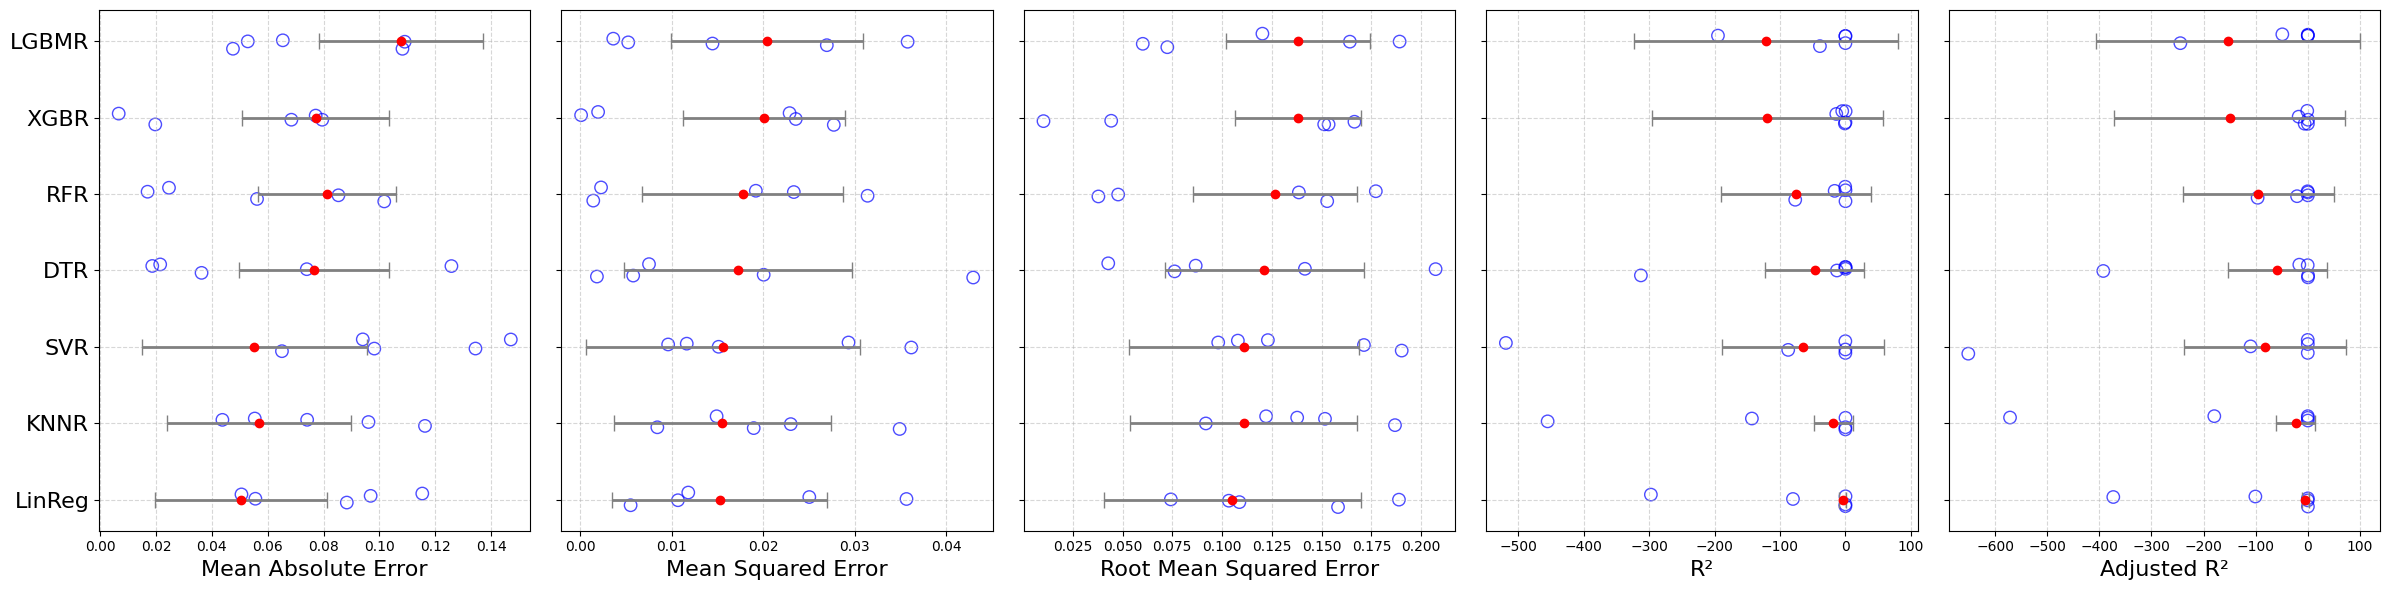

In [ ]:
metrics = ["MAE", "MSE", "RMSE", "R2", "Adj_R2"]
xlabel_map = {
    "MAE":  "Mean Absolute Error",
    "MSE":  "Mean Squared Error",
    "RMSE": "Root Mean Squared Error",
    "R2":   "R²",
    "Adj_R2": "Adjusted R²"
}

fig, axes = plt.subplots(1, len(metrics), figsize=(24, 6), sharey=True)

for ax, metric in zip(axes, metrics):
    for idx, (name, _) in enumerate(models):
        vals = cv_results[name][metric]
        y_jitter = idx + np.random.uniform(-0.1, 0.1, size=cv_folds)
        ax.scatter(
            vals,
            y_jitter,
            edgecolor="blue",
            facecolors="none",
            alpha=0.7,
            s=80
        )

    metric_name = "Adj R2" if metric == "Adj_R2" else metric
    means = summary_df[f"{metric_name} Mean"]
    stds  = summary_df[f"{metric_name} Std"]

    ax.errorbar(
        means.values,
        np.arange(len(models)),
        xerr=stds.values,
        fmt="o",
        color="red",
        ecolor="gray",
        elinewidth=2,
        capsize=6
    )

    ax.set_yticks(np.arange(len(models)))
    ax.set_yticklabels([name for name, _ in models], fontsize=16)
    ax.set_xlabel(xlabel_map[metric], fontsize=16)
    ax.grid(True, linestyle="--", alpha=0.5)
  

plt.tight_layout()
plt.show()